# Smart charging

How the smart charger decides when an EV charges, what that does to one session and to a fleet,
and what it costs in early departures and herding. Every price is synthetic and every £ figure
is illustrative (`evidence_kind="illustrative_synthetic"`): none is a tariff, a settlement or
Axle cash.

**The idea in one paragraph.** The *unmanaged* path charges at full home power from plug-in until
the EV reaches its preferred target. The *smart* path (decision 0004 item 38) plans each home
session when it starts, using only what it knows then: the battery at plug-in, the target, the
expected departure (the cohort's typical departure clock time minus a safety margin) and the
day-ahead prices already published. It buys just enough energy in the cheapest half-hours before
the expected departure. The plan is then run against the week's *actual* departure: a driver who
leaves earlier than expected leaves below target (an **early departure**). Because every smart EV
in a week sees the same prices, they all pick the same cheap half-hours, which makes a new, sharper
peak (**herding**).

Sections 1-2 stop there: one plan, built once at plug-in. That is not the whole fleet's story by
default. `trading.intraday_dispatch` (decision 0004 item 62(b); on by default;
`docs/contracts/intraday-dispatch-v1.md`) locks a committed share of EVs
(`trading.day_ahead_commitment_share`, 0.8 by default) to the plug-in plan just described for
their whole session, and lets the other, free share re-plan every hour against the latest known
price instead, moving charging out of a slot that has turned dear and into one that has turned
cheap. The fleet runs from section 3 on use the app's own default settings, so the *smart* (now
"selected") path they chart is already this dispatched fleet, not every EV frozen on its first
plan; notebook 06 looks at the dispatcher and its trading split directly.

The notebook calls the same functions the app does (`action.plan_cheapest_slots`,
`action.expected_departures_utc_ns`, `action.visible_day_ahead_prices`,
`forecast.run_forecast_from_assumptions`, `summaries.weekly_peak_summary`) and reads every value
from `model/assumptions.py`.

**Sections**

1. One toy session: `plan_cheapest_slots`
2. Expected departure minus the margin
3. A small fleet: unmanaged against smart home import
4. The margin trade-off: early departures against saving
5. Herding: each week's own peak and the coincidence factor
6. The noon-to-noon horizon and the warm-up
7. Sanity checks
8. Limitations

In [1]:
# --- MODEL IMPORTS (one cell) -----------------------------------------------
from datetime import date, datetime, time

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

from axle_studio.model import assumptions
from axle_studio.model.action import (
    expected_departures_utc_ns,
    plan_cheapest_slots,
    visible_day_ahead_prices,
)
from axle_studio.model.clock import utc_half_hour_boundaries
from axle_studio.model.forecast import run_forecast_from_assumptions
from axle_studio.model.summaries import weekly_peak_summary
from axle_studio.ui.style import PATH_LABELS, PATH_STYLES, apply_notebook_style, band_fill

# "notebook_connected" embeds only the figure data and loads plotly.js from a CDN, which keeps the
# committed notebook small. GitHub does not run that script, so every chart has a table under it.
pio.renderers.default = "notebook_connected"
pd.set_option("display.width", 120)
LONDON = "Europe/London"
HALF_HOUR = pd.Timedelta(minutes=30)

## Try it

The fleet runs are small so the notebook stays fast (a few seconds each); raise the counts for
steadier numbers. `MARGINS_H` are the departure margins compared in section 4; they include the
record's default. The toy session's plug-in SoC is a **toy value** chosen to make a visible plan,
not a model output: in a run, SoC at plug-in comes from the stock-flow simulation.

In [2]:
START_LOCAL_DATE = date(2026, 1, 12)  # the London date the seven study nights start (a Monday)
VEHICLE_COUNT = 100
WORLD_COUNT = 10  # simulated weeks
DEFAULT_MARGIN_H = assumptions.ACTION["departure_margin_hours"].value
MARGINS_H = (0.0, DEFAULT_MARGIN_H, 2 * DEFAULT_MARGIN_H)
TOY_COHORT = "average_uk"
TOY_PLUG_IN_SOC_PERCENT = 40.0  # toy value
TOY_PLUG_IN_LONDON = time(18, 0)
TOY_WEEK = 0

In [3]:
runs = {
    margin: run_forecast_from_assumptions(
        START_LOCAL_DATE,
        values={
            "vehicle_count": VEHICLE_COUNT,
            "evaluation_world_count": WORLD_COUNT,
            "departure_margin_hours": margin,
        },
    )
    for margin in MARGINS_H
}
base = runs[DEFAULT_MARGIN_H]
settings = base.replay_state.settings
kernel_units = base.replay_state.units
pd.DataFrame(
    [
        {
            "policy_id": base.policy_id,
            "evidence_kind": base.evidence_kind,
            "vehicles": base.vehicle_count,
            "simulated weeks": base.world_count,
            "warm-up days": settings.warmup_days,
            "study nights": settings.study_days,
            "default margin h (record)": DEFAULT_MARGIN_H,
        }
    ]
)

,policy_id,evidence_kind,vehicles,simulated weeks,warm-up days,study nights,default margin h (record)
0,explicit_synthetic_wholesale_v1,illustrative_synthetic,100,10,7,7,2.0


## 1. One toy session: `plan_cheapest_slots`

One `average_uk` EV plugs in at 18:00 on the first study evening. Its window runs from plug-in to
its expected departure (next section). The grid energy it needs is
`(target stock - stock at plug-in) / charging efficiency`, and one half-hour can import at most
`home charging power x 0.5 h`.

`plan_cheapest_slots` sorts the window's half-hours by price and fills the cheapest first: full
half-hours until the need is met, one partial half-hour, then nothing. With a linear cost and the
same cap in every half-hour, no plan can beat this, so an LP would give the same answer with more
machinery. Equal prices keep time order, so ties charge earlier, the safer choice when a driver
may leave early.

The prices it ranks come from `visible_day_ahead_prices` at the plug-in instant. At 18:00 the
next day's prices were published at 13:00, so every price in an overnight window is a real
day-ahead price.

For comparison, the same function given a flat price inside the window fills the earliest
half-hours first: that is the unmanaged "full power from plug-in" profile (the kernel uses the
same trick for a session whose charger ignores its plan).

In [4]:
ev = int(np.flatnonzero(base.units["cohort_id"].to_numpy() == TOY_COHORT)[0])
ev_traits = base.units.iloc[ev]
study_starts = pd.DatetimeIndex(base.study_slots["interval_start_utc"])
day_ahead = (
    base.forecast_prices["wholesale_forecast_gbp_per_mwh"]
    .to_numpy(dtype=float)
    .reshape(base.world_count, len(study_starts))
)
plug_in = pd.Timestamp(
    datetime.combine(START_LOCAL_DATE, TOY_PLUG_IN_LONDON), tz=LONDON
).tz_convert("UTC")
plug_in_slot = int(study_starts.get_loc(plug_in))

# The kernel's window rule (physics.py:_smart_charging_slot): the first expected departure at
# least one half-hour after plug-in, or the end of the study horizon, whichever comes first;
# only whole half-hours before it can charge.
departures = pd.to_datetime(
    expected_departures_utc_ns(settings, kernel_units, DEFAULT_MARGIN_H)[:, ev], utc=True
)
expected_departure = min(departures[departures >= plug_in + HALF_HOUR][0], base.horizon_end_utc)
window_slots = int((expected_departure - plug_in) // HALF_HOUR)

visible = visible_day_ahead_prices(day_ahead, study_starts, plug_in)[TOY_WEEK]
window = slice(plug_in_slot, plug_in_slot + window_slots)
window_price = visible[window]
capacity_kwh = ev_traits["physical_capacity_kwh"]
need_kwh = (
    (ev_traits["preferred_target_soc_percent"] - TOY_PLUG_IN_SOC_PERCENT) / 100 * capacity_kwh
) / settings.home_charge_efficiency
slot_cap_kwh = ev_traits["home_charger_limit_kw"] * 0.5

smart_kwh = plan_cheapest_slots(
    np.array([need_kwh]), np.array([slot_cap_kwh]), window_price[np.newaxis, :]
)[0]
unmanaged_kwh = plan_cheapest_slots(
    np.array([need_kwh]), np.array([slot_cap_kwh]), np.zeros((1, window_slots))
)[0]
pd.Series(
    {
        "cohort": ev_traits["cohort_label"],
        "battery kWh": capacity_kwh,
        "preferred target SoC %": ev_traits["preferred_target_soc_percent"],
        "plug-in SoC % (toy)": TOY_PLUG_IN_SOC_PERCENT,
        "charging efficiency": settings.home_charge_efficiency,
        "grid need kWh": round(need_kwh, 2),
        "most per half-hour kWh": slot_cap_kwh,
        "plug-in (London)": plug_in.tz_convert(LONDON).strftime("%a %H:%M"),
        "expected departure (London)": expected_departure.tz_convert(LONDON).strftime("%a %H:%M"),
        "window half-hours": window_slots,
    }
).to_frame("toy session")

,toy session
cohort,Average (UK)
battery kWh,60.0
preferred target SoC %,80.0
plug-in SoC % (toy),40.0
charging efficiency,0.92
grid need kWh,26.09
most per half-hour kWh,3.5
plug-in (London),Mon 18:00
expected departure (London),Tue 05:00
window half-hours,22


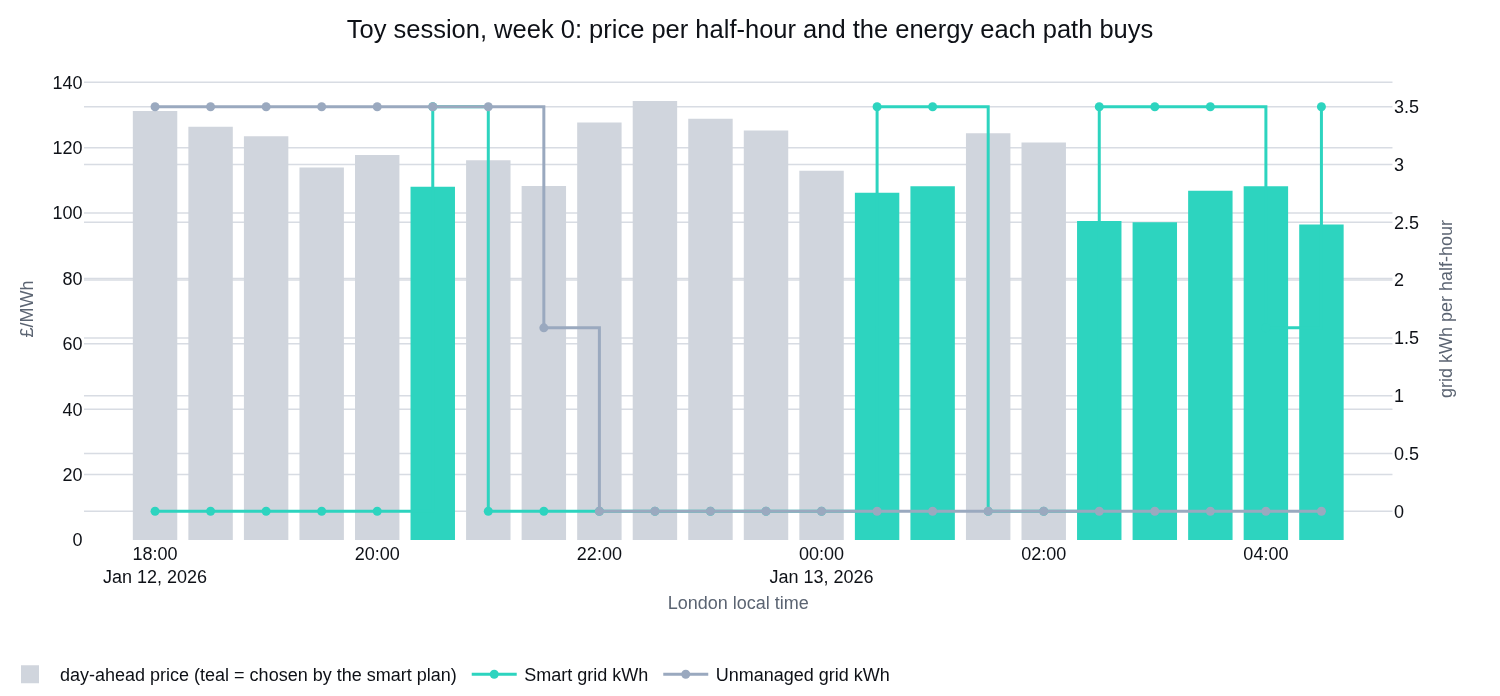

In [5]:
window_london = study_starts[window].tz_convert(LONDON)
session_figure = make_subplots(specs=[[{"secondary_y": True}]])
session_figure.add_trace(
    go.Bar(
        x=window_london,
        y=window_price.round(2),
        marker_color=np.where(smart_kwh > 0, PATH_STYLES["selected"]["color"], "#D0D5DD"),
        name="day-ahead price (teal = chosen by the smart plan)",
    ),
    secondary_y=False,
)
for path_id, kwh in (("selected", smart_kwh), ("normal", unmanaged_kwh)):
    session_figure.add_trace(
        go.Scatter(
            x=window_london,
            y=kwh.round(3),
            mode="lines+markers",
            line={"color": PATH_STYLES[path_id]["color"], "shape": "hv"},
            name=f"{PATH_LABELS[path_id]} grid kWh",
        ),
        secondary_y=True,
    )
session_figure.update_layout(
    title=f"Toy session, week {TOY_WEEK}: price per half-hour and the energy each path buys",
    xaxis_title="London local time",
)
session_figure.update_yaxes(title_text="£/MWh", secondary_y=False)
session_figure.update_yaxes(title_text="grid kWh per half-hour", secondary_y=True)
apply_notebook_style(session_figure, height=420)

In [6]:
session_table = pd.DataFrame(
    {
        "London": window_london.strftime("%a %H:%M"),
        "price £/MWh": window_price,
        "price rank": window_price.argsort(kind="stable").argsort() + 1,
        "smart kWh": smart_kwh,
        "unmanaged kWh": unmanaged_kwh,
    }
).round(2)
session_cost = pd.DataFrame(
    [
        {
            "path": PATH_LABELS[path_id],
            "grid kWh": kwh.sum(),
            "illustrative cost £": (kwh * window_price).sum() / 1000,
            "average price £/MWh": (kwh * window_price).sum() / kwh.sum(),
        }
        for path_id, kwh in (("normal", unmanaged_kwh), ("selected", smart_kwh))
    ]
).round(3)
display(session_cost)
session_table

,path,grid kWh,illustrative cost £,average price £/MWh
0,Unmanaged,26.087,3.102,118.894
1,Smart,26.087,2.694,103.254


,London,price £/MWh,price rank,smart kWh,unmanaged kWh
0,Mon 18:00,131.20,21,0.00,3.50
1,Mon 18:30,126.44,18,0.00,3.50
2,Mon 19:00,123.47,15,0.00,3.50
3,Mon 19:30,113.97,11,0.00,3.50
4,Mon 20:00,117.78,13,0.00,3.50
5,Mon 20:30,108.07,6,3.50,3.50
6,Mon 21:00,116.13,12,0.00,3.50
7,Mon 21:30,108.30,9,0.00,1.59
8,Mon 22:00,127.69,19,0.00,0.00
9,Mon 22:30,134.25,22,0.00,0.00


## 2. Expected departure minus the margin

The charger does not know when this driver will actually leave. It targets the cohort's typical
home departure clock time (weekday or weekend window, decision 0004 item 42) minus a safety margin
(`departure_margin_hours`; its default is in the setup table above, decision 0004 item 51). The
actual departure is a fat-tailed draw around the typical time (about ±2 h P5-P95, same item), so
the margin lowers the chance that a driver leaves before the plan has finished.

`expected_departures_utc_ns` gives one expected departure per London date and EV, converted at
each date's own London offset. The table shows Tuesday morning for one EV of each cohort.

In [7]:
tuesday = date.fromordinal(START_LOCAL_DATE.toordinal() + 1)
# Row 0 of expected_departures_utc_ns is the day before the study, so Tuesday is row 2.
tuesday_row = (tuesday - START_LOCAL_DATE).days + 1
first_of_cohort = base.units.drop_duplicates("cohort_id").index.to_numpy()
departure_table = pd.DataFrame(
    {
        "cohort": base.units.loc[first_of_cohort, "cohort_label"].to_numpy(),
        "typical weekday departure (h)": kernel_units.loc[
            first_of_cohort, "runtime_departure_local_hour"
        ].to_numpy(),
        **{
            f"expected, margin {margin:g} h": pd.to_datetime(
                expected_departures_utc_ns(settings, kernel_units, margin)[
                    tuesday_row, first_of_cohort
                ],
                utc=True,
            )
            .tz_convert(LONDON)
            .strftime("%a %H:%M")
            for margin in MARGINS_H
        },
    }
)
departure_table

,cohort,typical weekday departure (h),"expected, margin 0 h","expected, margin 2 h","expected, margin 4 h"
0,Intelligent Octopus average,7,Tue 07:00,Tue 05:00,Tue 03:00
1,Average (UK),7,Tue 07:00,Tue 05:00,Tue 03:00
2,Scheduled charging,9,Tue 09:00,Tue 07:00,Tue 05:00
3,Infrequent charging,7,Tue 07:00,Tue 05:00,Tue 03:00
4,Infrequent driving,7,Tue 07:00,Tue 05:00,Tue 03:00
5,Always plugged-in,14,Tue 14:00,Tue 12:00,Tue 10:00


## 3. A small fleet: unmanaged against smart home import

The full run (`run_forecast_from_assumptions`, the app's Run) simulates both paths over the same
EVs and the same random weeks, so the difference between them is the smart charger alone. Every
default applies, so `trading.intraday_dispatch` is on: the "Smart" path below is 80% EVs locked to
the plug-in plan section 1 built and 20% re-planning hourly on the latest known price (decision
0004 item 62(b)). The band is the spread across simulated weeks (P10-P90, P50 line), aggregated
world-first (decision 0004 item 12). The lower panel is the day-ahead price; a locked EV ranks it
throughout, and so does a free EV until its slot is published and it starts updating on the
intraday price instead.

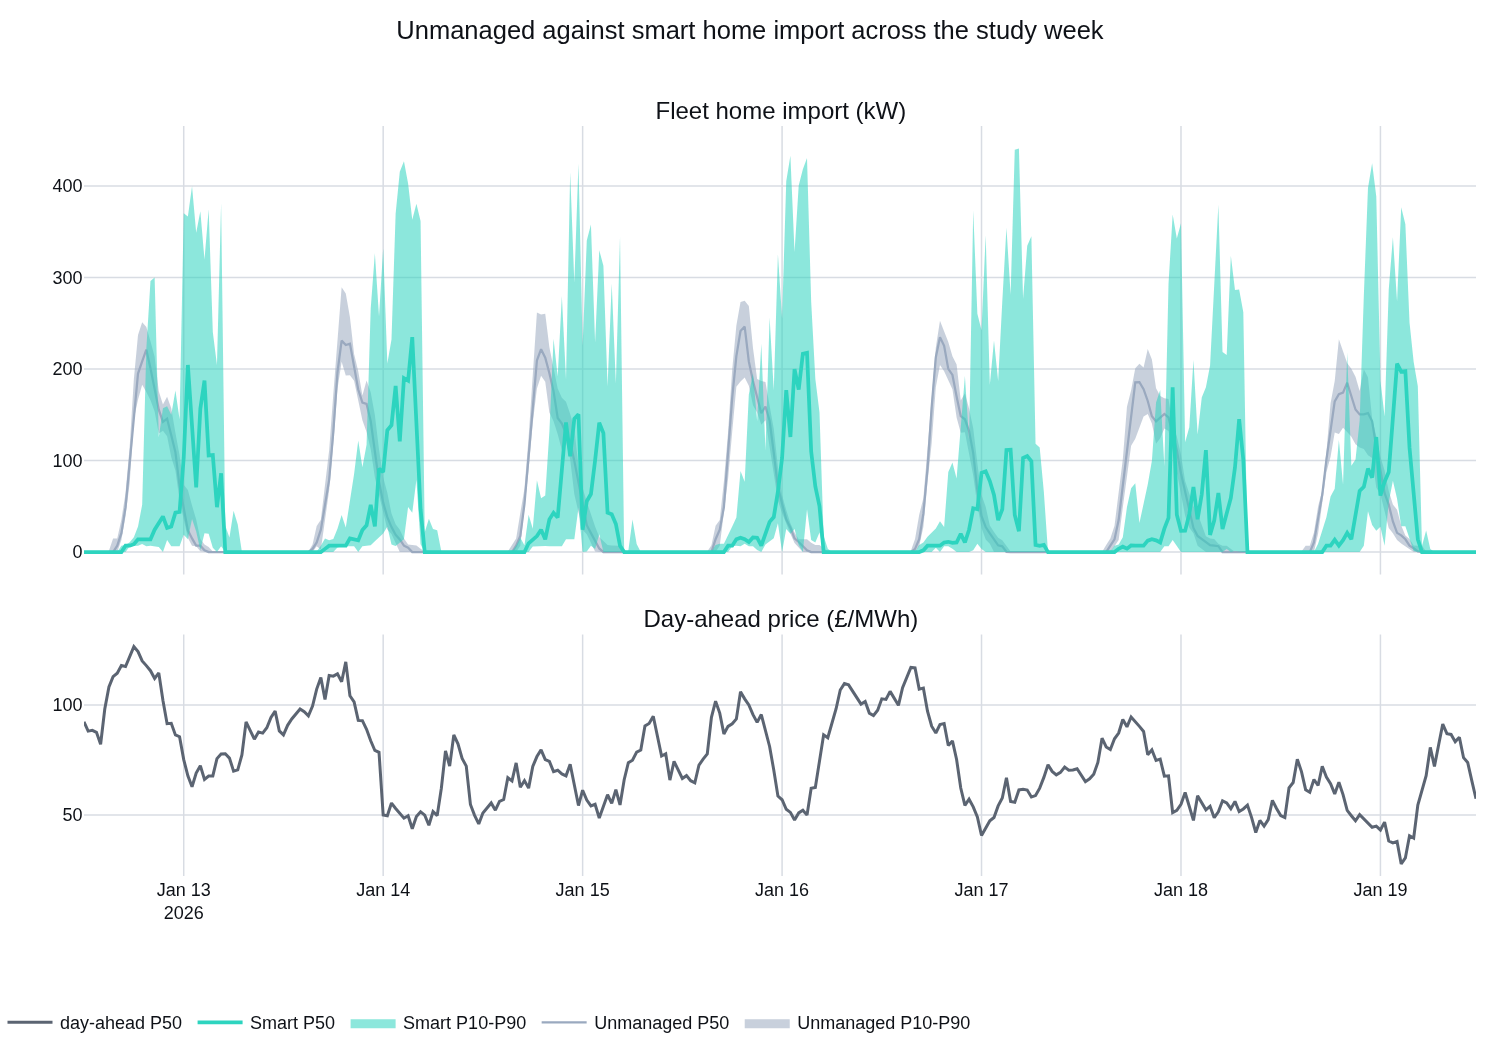

In [8]:
fleet_figure = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    row_heights=[0.65, 0.35],
    vertical_spacing=0.08,
    subplot_titles=["Fleet home import (kW)", "Day-ahead price (£/MWh)"],
)
home_import = base.fleet_interval_bands.query("metric == 'home_import_kw'")
for path_id in ("normal", "selected"):
    rows = home_import.query("path_id == @path_id").sort_values("slot_index")
    x = rows["interval_start_utc"].dt.tz_convert(LONDON)
    style = PATH_STYLES[path_id]
    fleet_figure.add_trace(
        go.Scatter(
            x=x, y=rows["p10"].round(2), line={"width": 0}, showlegend=False, hoverinfo="skip"
        ),
        row=1,
        col=1,
    )
    fleet_figure.add_trace(
        go.Scatter(
            x=x,
            y=rows["p90"].round(2),
            line={"width": 0},
            fill="tonexty",
            fillcolor=band_fill(style["color"]),
            name=f"{PATH_LABELS[path_id]} P10-P90",
        ),
        row=1,
        col=1,
    )
    fleet_figure.add_trace(
        go.Scatter(
            x=x,
            y=rows["p50"].round(2),
            line={"color": style["color"], "width": style["width"]},
            name=f"{PATH_LABELS[path_id]} P50",
        ),
        row=1,
        col=1,
    )
price_bands = base.forecast_price_bands.sort_values("slot_index")
fleet_figure.add_trace(
    go.Scatter(
        x=price_bands["interval_start_utc"].dt.tz_convert(LONDON),
        y=price_bands["p50"].round(2),
        line={"color": "#5B6472"},
        name="day-ahead P50",
    ),
    row=2,
    col=1,
)
fleet_figure.update_layout(title="Unmanaged against smart home import across the study week")
apply_notebook_style(fleet_figure, height=620)

In [9]:
# Per simulated week and night first, then the spread (world-first).
fleet_world = base.fleet_world_intervals.merge(
    base.study_slots[["slot_index", "night_index"]], on="slot_index"
)
nightly_kwh = (
    fleet_world.groupby(["path_id", "night_index", "world_id"])["home_import_kwh"]
    .sum()
    .groupby(["path_id", "night_index"])
    .median()
    .unstack("path_id")
    .rename(columns=PATH_LABELS)
)
nightly_kwh.columns = [f"{name} home kWh (P50 over weeks)" for name in nightly_kwh.columns]
display(nightly_kwh.round(1))
base.smart_charging_summary.round(3)

,Unmanaged home kWh (P50 over weeks),Smart home kWh (P50 over weeks)
night_index,,
0,1103.8,1101.5
1,1209.5,1215.0
2,1083.2,1086.7
3,1199.5,1197.8
4,1106.1,1107.8
5,1179.2,1168.3
6,1212.8,1217.7


,metric,unit,world_count,mean,p10,p50,p90
0,normal_average_price_gbp_per_mwh,GBP/MWh,10,83.614,56.413,83.051,113.275
1,selected_average_price_gbp_per_mwh,GBP/MWh,10,48.550,22.735,47.599,72.598
2,average_price_change_gbp_per_mwh,GBP/MWh,10,-35.064,-40.103,-36.067,-28.830
3,moved_home_import_share,fraction,10,0.700,0.594,0.725,0.766
4,early_departure_count,sessions per week,10,4.600,2.000,4.500,6.500
5,early_departure_shortfall_kwh,kWh per week,10,16.806,6.204,17.462,30.622


## 4. The margin trade-off: early departures against saving

A bigger margin ends the plan earlier: fewer drivers leave before it finishes, but the plan has
fewer cheap half-hours to choose from, so it saves less. Each margin below is a full run with the
same seed, so the weeks and drivers are identical and only the margin changes. An early departure
here is a smart session that ended before its plan finished (`early_departure_count`); its
shortfall is later met by public top-ups or valued as energy not recovered (decision 0004 items
4, 5 and 13).

In [10]:
def summary_value(result, metric: str, stat: str = "mean") -> float:
    """One statistic of one smart-charging metric from a run's contract summary table."""
    table = result.smart_charging_summary.set_index("metric")
    return float(table.at[metric, stat])


margin_table = pd.DataFrame(
    [
        {
            "margin h": margin,
            "early departures per week (mean)": summary_value(result, "early_departure_count"),
            "early-departure shortfall kWh per week (mean)": summary_value(
                result, "early_departure_shortfall_kwh"
            ),
            "smart minus unmanaged average price £/MWh (mean)": summary_value(
                result, "average_price_change_gbp_per_mwh"
            ),
            "illustrative smart minus unmanaged total £ per week (P50)": float(
                result.cost_effect_summary.set_index("component").at["total", "p50"]
            ),
        }
        for margin, result in runs.items()
    ]
).round(3)
margin_table

,margin h,early departures per week (mean),early-departure shortfall kWh per week (mean),smart minus unmanaged average price £/MWh (mean),illustrative smart minus unmanaged total £ per week (P50)
0,0.0,32.5,174.187,-36.861,-256.710
1,2.0,4.6,16.806,-35.064,-298.073
2,4.0,2.4,14.836,-31.153,-224.771


The last column adds what early departures cost later: the public top-ups and the energy not
recovered by the end of the week, priced at the illustrative public rate. So the margin with the
biggest price saving need not give the biggest total saving.

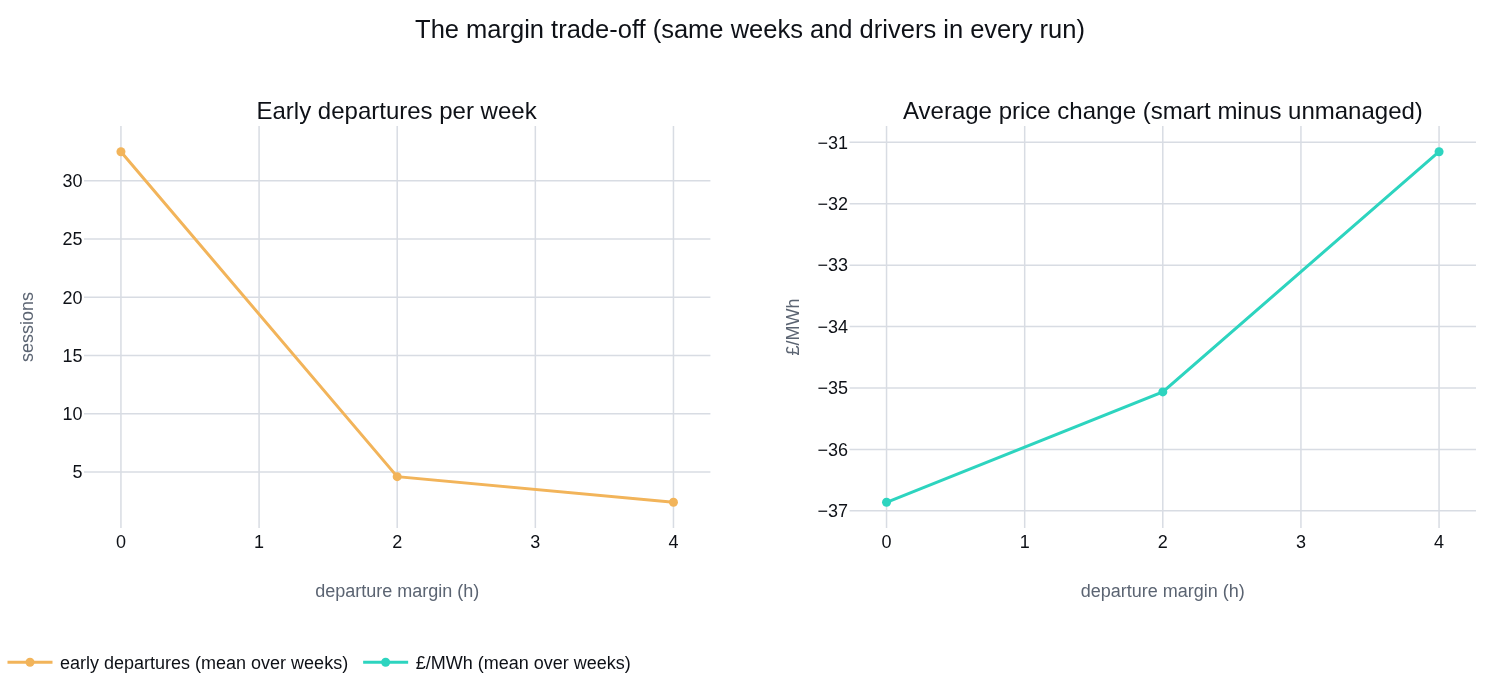

In [11]:
margin_figure = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["Early departures per week", "Average price change (smart minus unmanaged)"],
)
margin_figure.add_trace(
    go.Scatter(
        x=margin_table["margin h"],
        y=margin_table["early departures per week (mean)"],
        mode="lines+markers",
        line={"color": PATH_STYLES["difference"]["color"]},
        name="early departures (mean over weeks)",
    ),
    row=1,
    col=1,
)
margin_figure.add_trace(
    go.Scatter(
        x=margin_table["margin h"],
        y=margin_table["smart minus unmanaged average price £/MWh (mean)"],
        mode="lines+markers",
        line={"color": PATH_STYLES["selected"]["color"]},
        name="£/MWh (mean over weeks)",
    ),
    row=1,
    col=2,
)
margin_figure.update_xaxes(title_text="departure margin (h)")
margin_figure.update_yaxes(title_text="sessions", col=1)
margin_figure.update_yaxes(title_text="£/MWh", col=2)
margin_figure.update_layout(title="The margin trade-off (same weeks and drivers in every run)")
apply_notebook_style(margin_figure, height=380)

## 5. Herding: each week's own peak and the coincidence factor

Inside one simulated week every smart EV ranks the same national day-ahead prices, so they pile
onto the same cheap half-hours. That can make a sharper fleet peak than unmanaged charging, whose
plug-ins are spread through the evening. There is no site or network limit in the default model,
so this is reported as a finding, not fixed (decision 0004 items 48 and 49).

`weekly_peak_summary` measures it the right way round: **each week's own peak first**, then the
spread across weeks. Which half-hour is cheapest moves from week to week, so the peak of the
median band would smear the pile-up out and understate it. The **coincidence factor** (decision
0004 item 54) is the week's peak divided by the charger capacity plugged in at that half-hour
(plugged-in EVs x home charging power): 1 means every plugged-in EV was drawing full power.

In [12]:
home_power_kw = float(base.units["home_charger_limit_kw"].unique().item())
peaks = weekly_peak_summary(base.fleet_world_intervals, home_charging_power_kw=home_power_kw)
peak_columns = [
    "path_id",
    "p10",
    "p50",
    "p90",
    "modal_peak_interval_start_london",
    "modal_peak_week_count",
    "ratio_to_normal_p50",
    "coincidence_factor_p10",
    "coincidence_factor_p50",
    "coincidence_factor_p90",
]
peaks[peak_columns].round(3)

,path_id,p10,p50,p90,modal_peak_interval_start_london,modal_peak_week_count,ratio_to_normal_p50,coincidence_factor_p10,coincidence_factor_p50,coincidence_factor_p90
0,normal,254.897,279.968,294.477,2026-01-13 19:00:00+00:00,2,1.000,0.538,0.568,0.620
1,selected,421.931,464.745,493.822,2026-01-13 01:00:00+00:00,1,1.687,0.724,0.766,0.802


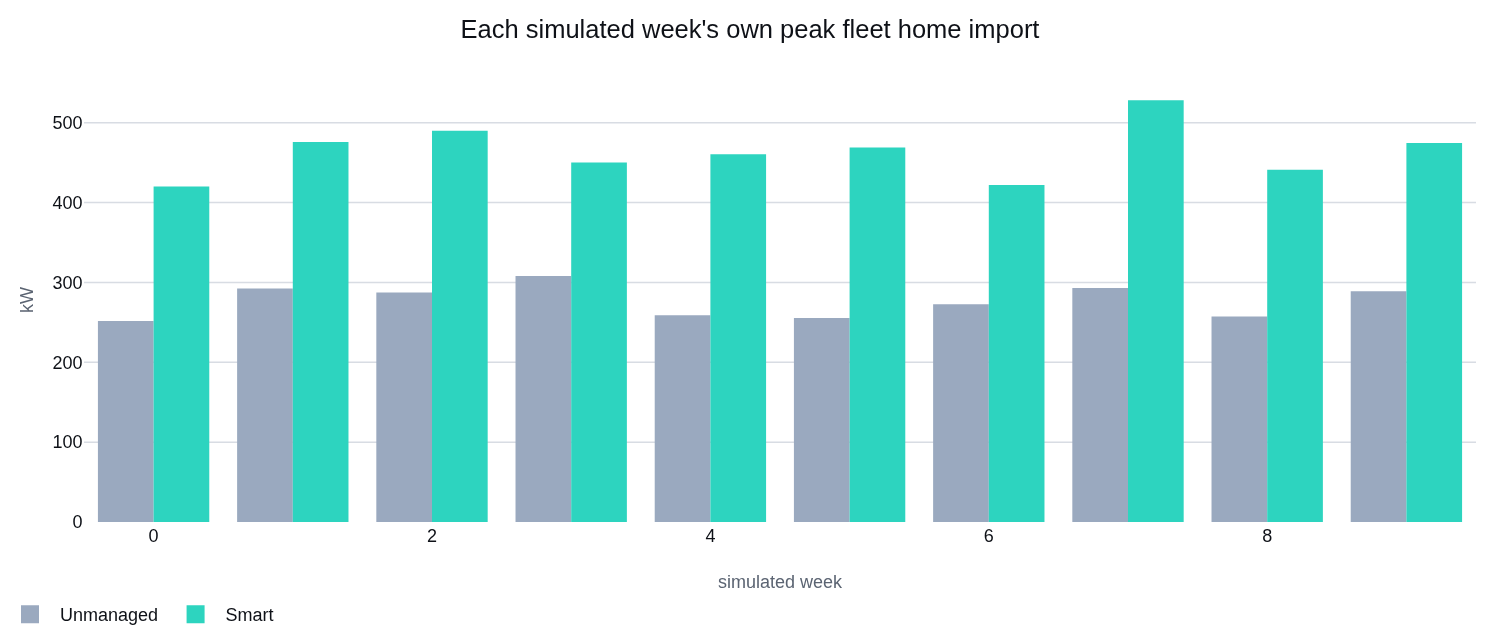

In [13]:
week_peaks = (
    base.fleet_world_intervals.groupby(["world_id", "path_id"])["home_import_kw"]
    .max()
    .unstack("path_id")
)
peak_figure = go.Figure()
for path_id in ("normal", "selected"):
    peak_figure.add_trace(
        go.Bar(
            x=week_peaks.index,
            y=week_peaks[path_id].round(1),
            marker_color=PATH_STYLES[path_id]["color"],
            name=PATH_LABELS[path_id],
        )
    )
peak_figure.update_layout(
    barmode="group",
    title="Each simulated week's own peak fleet home import",
    xaxis_title="simulated week",
    yaxis_title="kW",
)
apply_notebook_style(peak_figure, height=380)

In [14]:
week_peaks.rename(columns=PATH_LABELS).assign(
    **{"smart ÷ unmanaged": lambda frame: frame["Smart"] / frame["Unmanaged"]}
).round(2)

path_id,Unmanaged,Smart,smart ÷ unmanaged
world_id,,,
0,251.69,420.00,1.67
1,292.53,476.00,1.63
2,287.31,490.00,1.71
3,307.92,450.11,1.46
4,258.96,460.49,1.78
5,255.25,469.00,1.84
6,272.62,422.15,1.55
7,292.98,528.22,1.80
8,257.34,441.00,1.71


One week in detail: the representative week (the one closest to the median), fleet home import
on both paths. The smart path's energy arrives in a few tall blocks at each night's cheapest
half-hours.

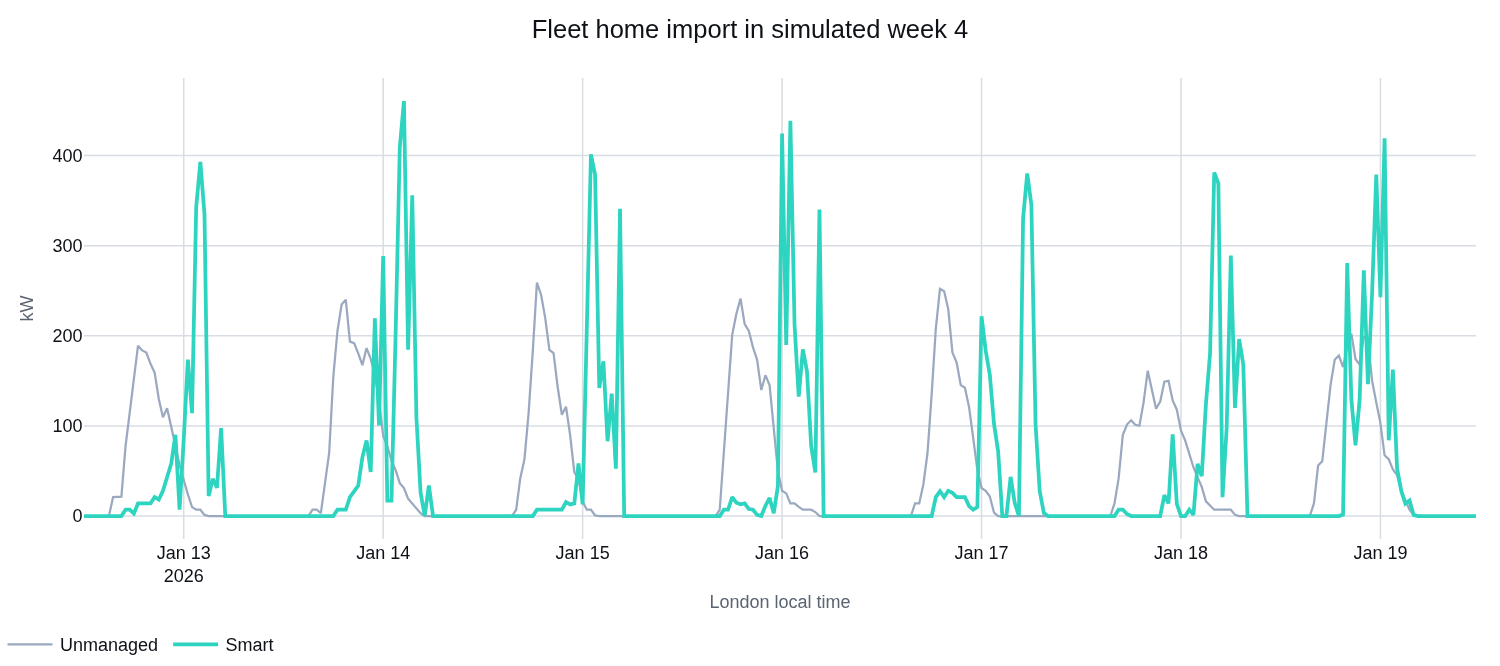

In [15]:
representative = base.fleet_world_intervals.query("world_id == @base.representative_world_id")
week_figure = go.Figure()
for path_id in ("normal", "selected"):
    rows = representative.query("path_id == @path_id").sort_values("slot_index")
    week_figure.add_trace(
        go.Scatter(
            x=rows["interval_start_utc"].dt.tz_convert(LONDON),
            y=rows["home_import_kw"].round(2),
            line={"color": PATH_STYLES[path_id]["color"], "width": PATH_STYLES[path_id]["width"]},
            name=PATH_LABELS[path_id],
        )
    )
week_figure.update_layout(
    title=f"Fleet home import in simulated week {base.representative_world_id}",
    xaxis_title="London local time",
    yaxis_title="kW",
)
apply_notebook_style(week_figure, height=400)

In [16]:
representative.merge(base.study_slots[["slot_index", "night_index"]], on="slot_index").groupby(
    ["night_index", "path_id"]
)["home_import_kw"].max().unstack("path_id").rename(columns=PATH_LABELS).rename(
    columns=lambda name: f"{name} peak kW"
).round(1)

path_id,Unmanaged peak kW,Smart peak kW
night_index,,
0,189.0,393.0
1,240.2,460.5
2,259.0,401.3
3,241.2,438.7
4,252.2,380.2
5,161.3,381.3
6,202.3,419.2


## 6. The noon-to-noon horizon and the warm-up

The study runs from London 12:00 on the start date for seven **session nights** (decision 0004
item 52), so every overnight session sits inside it and every night is a smart-charging night.
Before it, a warm-up (`SIMULATION["warmup_days"]`) is simulated but not shown: it gives the
batteries a settled starting state, the charger its published price history, and the trading
baseline its reference nights.

Both paths share the warm-up history except its **last night**, where smart planning already
runs. So the first study night opens with batteries a smart charger left, and is a real smart
night rather than a catch-up from unmanaged batteries. The charger's inputs record this directly:
`price_epoch_by_slot` is -1 (no planning) for every warm-up slot before the last warm-up night.

In [17]:
run_starts = pd.DatetimeIndex(
    utc_half_hour_boundaries(START_LOCAL_DATE, settings.warmup_days, settings.study_days)[:-1]
)
epoch = base.replay_state.smart_charging.price_epoch_by_slot
first_plan_slot = int(np.flatnonzero(epoch >= 0)[0])
horizon_table = pd.Series(
    {
        "study starts (London)": base.horizon_start_utc.tz_convert(LONDON).strftime(
            "%a %d %b %H:%M"
        ),
        "study ends (London)": base.horizon_end_utc.tz_convert(LONDON).strftime("%a %d %b %H:%M"),
        "study half-hours": base.study_slot_count,
        "warm-up days": settings.warmup_days,
        "warm-up half-hours without planning": int((epoch == -1).sum()),
        "first planned half-hour (London)": run_starts[first_plan_slot]
        .tz_convert(LONDON)
        .strftime("%a %d %b %H:%M"),
    }
).to_frame("value")
horizon_table

,value
study starts (London),Mon 12 Jan 12:00
study ends (London),Mon 19 Jan 12:00
study half-hours,336
warm-up days,7
warm-up half-hours without planning,288
first planned half-hour (London),Sun 11 Jan 12:00


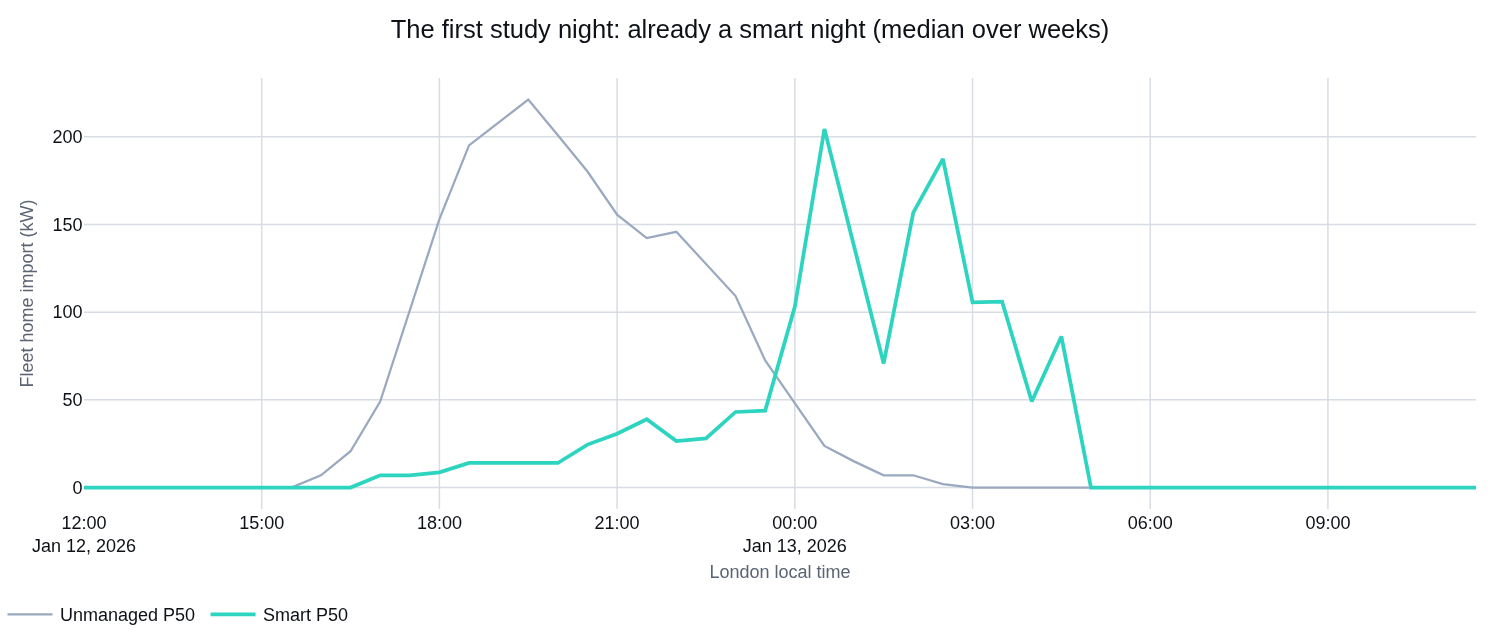

In [18]:
night_zero = fleet_world.query("night_index == 0").merge(
    base.forecast_prices[["world_id", "slot_index", "wholesale_forecast_gbp_per_mwh"]],
    on=["world_id", "slot_index"],
)
night_zero["cost"] = night_zero["home_import_kwh"] * night_zero["wholesale_forecast_gbp_per_mwh"]
first_night = (
    night_zero.groupby(["world_id", "path_id"])[["home_import_kwh", "cost"]]
    .sum()
    .assign(average_price=lambda frame: frame["cost"] / frame["home_import_kwh"])
    .reset_index()
)
first_night_prices = first_night.pivot(
    index="world_id", columns="path_id", values="average_price"
).rename(columns=PATH_LABELS)

first_night_figure = go.Figure()
for path_id in ("normal", "selected"):
    rows = (
        night_zero.query("path_id == @path_id")
        .groupby("interval_start_utc")["home_import_kw"]
        .median()
    )
    first_night_figure.add_trace(
        go.Scatter(
            x=rows.index.tz_convert(LONDON),
            y=rows.round(2),
            line={"color": PATH_STYLES[path_id]["color"], "width": PATH_STYLES[path_id]["width"]},
            name=f"{PATH_LABELS[path_id]} P50",
        )
    )
first_night_figure.update_layout(
    title="The first study night: already a smart night (median over weeks)",
    xaxis_title="London local time",
    yaxis_title="Fleet home import (kW)",
)
apply_notebook_style(first_night_figure, height=380)

In [19]:
first_night_prices.rename(columns=lambda name: f"{name} average price £/MWh, night 0").round(2)

path_id,"Unmanaged average price £/MWh, night 0","Smart average price £/MWh, night 0"
world_id,,
0,120.84,102.80
1,65.97,33.14
2,76.02,48.09
3,54.19,50.62
4,173.27,124.15
5,115.15,96.83
6,125.54,60.15
7,112.13,62.82
8,117.78,92.02


## 7. Sanity checks

In [20]:
chosen = smart_kwh > 0
checks = {
    "toy plan buys exactly the need": np.isclose(smart_kwh.sum(), need_kwh),
    "toy plan respects the half-hour cap": bool((smart_kwh <= slot_cap_kwh + 1e-12).all()),
    "toy plan: every chosen half-hour is no dearer than every unchosen one": window_price[
        chosen
    ].max()
    <= window_price[~chosen].min(),
    "toy plan: the unmanaged profile fills the earliest half-hours": bool(
        np.all(np.diff(unmanaged_kwh) <= 0)
    ),
    "toy plan costs no more than unmanaged": (smart_kwh * window_price).sum()
    <= (unmanaged_kwh * window_price).sum(),
    "toy window prices are all published at plug-in": np.array_equal(
        window_price, day_ahead[TOY_WEEK, window]
    ),
    "expected departure is the typical time minus the margin": all(
        np.array_equal(
            expected_departures_utc_ns(settings, kernel_units, 0.0)
            - expected_departures_utc_ns(settings, kernel_units, margin),
            np.full((settings.study_days + 3, settings.vehicle_count), int(margin * 3600e9)),
        )
        for margin in MARGINS_H
    ),
    "smart pays a lower average price than unmanaged in every week": bool(
        (
            base.smart_charging_world["selected_average_price_gbp_per_mwh"]
            < base.smart_charging_world["normal_average_price_gbp_per_mwh"]
        ).all()
    ),
    "a bigger margin gives no more early departures": bool(
        np.all(np.diff(margin_table["early departures per week (mean)"]) <= 0)
    ),
    "a bigger margin saves no more on price": bool(
        np.all(np.diff(margin_table["smart minus unmanaged average price £/MWh (mean)"]) >= 0)
    ),
    "weekly_peak_summary matches the run's own table": peaks.equals(base.weekly_peak_summary),
    "herding: the smart peak is above the unmanaged peak in most weeks": (
        week_peaks["selected"] > week_peaks["normal"]
    ).mean()
    > 0.5,
    "coincidence factors lie between 0 and 1": bool(
        peaks[["coincidence_factor_p10", "coincidence_factor_p90"]].stack().between(0, 1).all()
    ),
    "the study runs noon to noon": base.horizon_start_utc.tz_convert(LONDON).hour == 12
    and base.horizon_end_utc.tz_convert(LONDON).hour == 12,
    "planning starts on the last warm-up night": first_plan_slot == 48 * (settings.warmup_days - 1),
    "the first study night is already cheaper on the smart path": bool(
        (first_night_prices["Smart"] < first_night_prices["Unmanaged"]).all()
    ),
}
check_table = pd.Series(checks, name="passes").to_frame()
assert check_table["passes"].all(), check_table[~check_table["passes"]]
check_table

,passes
toy plan buys exactly the need,True
toy plan respects the half-hour cap,True
toy plan: every chosen half-hour is no dearer than every unchosen one,True
toy plan: the unmanaged profile fills the earliest half-hours,True
toy plan costs no more than unmanaged,True
toy window prices are all published at plug-in,True
expected departure is the typical time minus the margin,True
smart pays a lower average price than unmanaged in every week,True
a bigger margin gives no more early departures,True
a bigger margin saves no more on price,True


## 8. Limitations

- Prices are synthetic and national, so every smart EV in a week ranks the same prices; herding is
  a finding of that, with no site, network or supplier limit to spread it (decision 0004 item 48).
- Section 1's toy session and the plan any EV is given at plug-in still work exactly as described:
  one plan, on the day-ahead prices published by then. That plan is not fixed for the whole fleet,
  though: by default (`trading.intraday_dispatch`, decision 0004 item 62(b);
  `docs/contracts/intraday-dispatch-v1.md`) the free share of EVs (20%,
  `trading.day_ahead_commitment_share` = 0.8 by default) re-plans every hour against the latest
  known price, and the fleet runs of sections 3-5 already have that switched on. Only the locked
  share (and any non-responder) keeps the plug-in plan for its whole session.
- The expected departure is the cohort's typical clock time minus one fleet-wide margin; a real
  charger might learn each driver's habits.
- One home charging power for every EV (decision 0004 item 34).
- The toy session's plug-in SoC is a toy value; in runs, SoC at plug-in is a stock-flow output.
- The small runs here (a hundred EVs, ten weeks) are for speed; their spreads are wider and their
  percentiles rougher than the app's default run.
- The toy window (section 1) follows the kernel's own rule (`physics.py:_smart_charging_slot`) by
  construction rather than being cross-checked against it: a one-EV replay
  (`individual.replay_one_ev`) exposes only the kernel's per-slot import, not the internal plan
  (`start`, `end`, `remaining_kwh`) it was computed from, so a direct kernel cross-check is not
  available here.